# Clovia Chebet
**This is Machine Learning class**
* We will use titanic datasets

### Importing Libraries
 Imported the necessary libraries for going through the datasets;
* **pandas**:It lets us organize, clean, filter, and analyze data tables.
* **numpy**: It handles complex math calculations and manages large lists of numbers very quickly.
* **matplotlib.pyplot**:It is used to build visual graphics like bar charts and graphs so we can see patterns in our data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Dataset Loading
* **pd.read_csv("titanic.csv")**: This tells the Pandas library to open and read a spreadsheet file named titanic.csv.
* **df_titanic =**: This saves the loaded spreadsheet into a Python data table (called a DataFrame).It Saves it as df_titanic


In [2]:
df_titanic=pd.read_csv("titanic.csv")

### Dataset content
*Checked the first five rows of the dataset*

In [3]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### About the datasets
* Checked the overview(size) of our dataset(titanic)



In [4]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


### Fixing Ages for "Master"
* Fixed the ages for names with "Master" by finding the mean and replacing the blank age values for "Master" with that group mean.


In [5]:
mask= df_titanic["Name"].str.contains("Master", na=False)
master_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(master_age_mean)

### Fixing Ages for "Mr"
* Fixed the ages for names with "Mr" by finding the mean and replacing the blank age values for "Mr" with that group mean.


In [6]:
mask= df_titanic["Name"].str.contains("Mr", na=False)
mr_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(mr_age_mean)


### Fixing Ages for "Miss"
* Looked for rows where the passenger name contains "Miss".Calculated the average age for this female group and replaced blank age values for "Miss" with that group average.


In [7]:
mask= df_titanic["Name"].str.contains("Miss", na=False)
miss_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(miss_age_mean)


### Fixing Ages for "Mrs"
* Looked for rows where the passenger name contains "Mrs".Calculated the average age for this female group and replaced blank age values for "Mrs" with that group average.


In [8]:
mask= df_titanic["Name"].str.contains("Mrs", na=False)
mrs_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(mrs_age_mean)

### Fixing Ages for "Dr"
* Found rows where the passenger name contains "Dr".Calculated the average age for doctors.Replaced blank age values for "Dr" with that group average.


In [9]:
mask= df_titanic["Name"].str.contains("Dr", na=False)
dr_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(dr_age_mean)

### Fixing Ages for "Ms"
* Fixed the ages for names with "Ms" by finding the mean and replacing the blank age values for "Ms" with that group mean.


In [10]:
mask= df_titanic["Name"].str.contains("Ms", na=False)
ms_age_mean= df_titanic.loc[mask, "Age"].mean()
df_titanic.loc[mask,"Age"]=df_titanic.loc[mask,"Age"].fillna(ms_age_mean)

### Targeted Data Fix
* Located the exact row for "Stone, Mrs. George Nelson", found where he embarked and filled the empty part.


In [11]:
mask_stone = df_titanic['Name'].str.contains('Stone, Mrs. George Nelson', na=False)
df_titanic.loc[mask_stone, 'Embarked'] = 'S'

### Targeted Data Fix
* Located the exact row for "Icard, Miss. Amelie", found where she embarked and filled the empty part.


In [12]:
mask = df_titanic['Name'].str.contains('Icard, Miss. Amelie', na=False)
df_titanic.loc[mask, 'Embarked'] = 'S'

### Fixing Missing Fares
* Finding any empty or missing slots in the `Fare` column.Calculate the middle value of all ticket prices and fill any blank fare amounts with the dataset's median ticket price.


In [13]:
df_titanic['Fare'] = df_titanic['Fare'].fillna(df_titanic['Fare'].median())

### Separating the target
* Removed the survived column from the dataset since we will use it as our target*

In [14]:
X= df_titanic.drop(['Survived'], axis=1)

### Dropping the Target Variable
* Selecting only the survival results column from the data.Saves these answers into a single separate list named y.


In [15]:
y=df_titanic['Survived']

# Display the updated dataset
*displayed the first five rows of the x-axis*

In [16]:
X.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Previewing Target Data
* Displaying the first 5 values of our survival answers list.


In [17]:
y.head(5)

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Plotting 
*Plotted our dataset values in a graph*

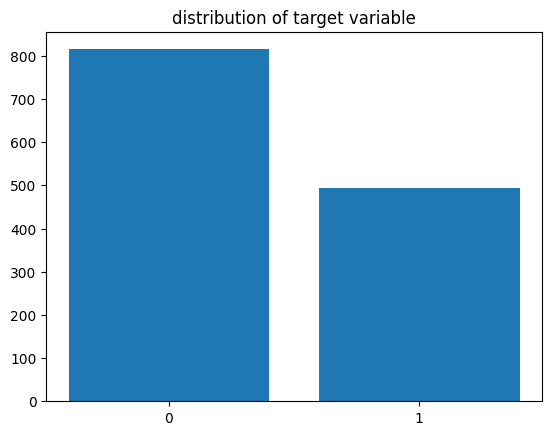

In [18]:
x=y.value_counts()
plt.bar(x.index,x)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

### Importing LabelEncoder
* Imported a tool used to turn text into numbers.Computer models only understand math, so we need this to convert words (like "male" and "female") into numbers (like 0 and 1).


In [19]:
from sklearn.preprocessing import LabelEncoder

### Converting Text to Numbers
* Changed columns containing text values (`object`) into number values leaveing columns that are already numbers completely alone.


In [20]:
train=pd.DataFrame()
label=LabelEncoder()
for c in  X.columns:
    if(X[c].dtype=='object'):
        train[c]=label.fit_transform(X[c])
    else:
        train[c]=X[c]



### Importing Machine Learning Tools
**Imported necessary libraries**
* train_test_split: a tool used to split our data into training parts and testing parts.
* LogisticRegression: computer model we will use to predict survival.
* accuracy_score: A tool to grade our model and see what percentage of its guesses were correct.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import base

                                             

### Creating a Training Function
* **`def logistic(X,y):`**: Creates a custom shortcut function to train and test our model automatically.
* **`train_test_split`**: Saves 80% of the data for learning and hides 20% for testing.
* **`lr.fit()`**: Teaches the model how to look for patterns to predict survival.
* **`lr.predict()`**: Asks the model to guess the survival outcomes for the test group.
* **`print('Accuracy : '...)`**: Displays the final test score of our model.


In [22]:
def logistic(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    y_pre=lr.predict(X_test)
    print('Accuracy : ',accuracy_score(y_test,y_pre))

### Checking the Features
* Displaying the top 5 rows of our feature dataset.


In [23]:
X.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Removing the Cabin Column
* Deleted the Cabin column from the table since it has too many missing blanks to be useful.


In [24]:
df_titanic.drop(['Cabin'], axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,33.322090,0,0,A.5. 3236,8.0500,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,S
1307,1308,0,3,"Ware, Mr. Frederick",male,33.322090,0,0,359309,8.0500,S


### Running the Model
* Running the custom function to train and test the model on the processed data.


In [25]:
logistic(train,y)

Accuracy :  0.8244274809160306


/home/student/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Importing OneHotEncoder
* Importing a data tool used to convert category words into numbers.


In [26]:
from sklearn.preprocessing import OneHotEncoder

### Splitting the Sex Column
* Created the text splitting tool for the Sex.


In [27]:

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df_titanic[['Sex']])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Sex']))

print(one_hot_df.head())

   Sex_female  Sex_male
0         0.0       1.0
1         1.0       0.0
2         1.0       0.0
3         1.0       0.0
4         0.0       1.0


### Splitting the Embarked Column
* Created the text splitting tool for the embarked locations.


In [28]:
encoder_emb = OneHotEncoder(sparse_output=False)
emb_encoded = encoder_emb.fit_transform(df_titanic[['Embarked']])
emb_df = pd.DataFrame(emb_encoded, columns=encoder_emb.get_feature_names_out(['Embarked']))

print(emb_df.head())


   Embarked_C  Embarked_Q  Embarked_S
0         0.0         0.0         1.0
1         1.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         0.0         0.0         1.0


In [29]:
logistic(train,y)

Accuracy :  0.8244274809160306


/home/student/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
